Configuração inicial

In [163]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None) # Limite de colunas que serão mostradas
pd.set_option("display.max_rows", 100) # Limite de linhas que serão mostradas

plt.rcParams["figure.figsize"] = (10,6) # Tamanho das figuras, largura e altura

Importação da base

In [164]:
df_acre = pd.read_csv("base_dados/MICRODADOS_ENEM_2023_AC.csv")
print("Base carregada com sucesso.")

Base carregada com sucesso.


Checagem dos valores nulos

In [165]:
df_nulos = df_acre.isnull().sum().sort_values(ascending=False) # Contagem de nulos e ordenação decrescente
df_nulos = df_nulos.to_frame("Quantidade de nulos")
df_nulos["Porcentagem"] = (df_acre.isnull().sum() / len(df_acre) * 100).sort_values(ascending=False) # Coluna de porcentagem

print(df_nulos)

                        Quantidade de nulos  Porcentagem
SG_UF_ESC                             20077    82.709895
NO_MUNICIPIO_ESC                      20077    82.709895
TP_SIT_FUNC_ESC                       20077    82.709895
TP_DEPENDENCIA_ADM_ESC                20077    82.709895
TP_LOCALIZACAO_ESC                    20077    82.709895
CO_MUNICIPIO_ESC                      20077    82.709895
CO_UF_ESC                             20077    82.709895
TP_ENSINO                             17746    73.107028
NU_NOTA_CN                             9120    37.571064
NU_NOTA_MT                             9120    37.571064
CO_PROVA_MT                            9120    37.571064
CO_PROVA_CN                            9120    37.571064
NU_NOTA_COMP3                          8112    33.418472
CO_PROVA_CH                            8112    33.418472
NU_NOTA_CH                             8112    33.418472
NU_NOTA_LC                             8112    33.418472
CO_PROVA_LC                    

In [166]:
colunas_notas = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']

df_removidos = df_acre.dropna(subset=colunas_notas).copy() # Retira linhas que possuem algum valor de nota nulo

print(df_acre.shape)
print(df_removidos.shape)

(24274, 65)
(15099, 65)


# Análise dos dados envolvendo escola

## Mapeamento das colunas de escolas

In [167]:
df_escolas = df_acre.dropna(subset=['TP_DEPENDENCIA_ADM_ESC', 'TP_LOCALIZACAO_ESC']).copy() # Retira linhas que não possuem esses dados

# Filtra apenas escolas Públicas (2) e Privadas (3)
df_escolas = df_acre[df_acre['TP_ESCOLA'].isin([2, 3])].copy()

mapeamento_localizacao = {1: 'Urbana', 2: 'Rural'}
mapeamento_tp_escola = {2: "Pública", 3: "Privada"}

df_escolas['LOCALIZACAO_ESC'] = df_escolas['TP_LOCALIZACAO_ESC'].map(mapeamento_localizacao)
df_escolas['TP_ESCOLA'] = df_escolas['TP_ESCOLA'].map(mapeamento_tp_escola)

Preenchimento de notas vazias pela mediana

In [168]:

# Preenche dados ausentes pela mediana da coluna
for coluna_nota in colunas_notas:
    df_escolas[coluna_nota] = df_escolas[coluna_nota].fillna(df_escolas[coluna_nota].median())
df_escolas.shape

(6967, 66)

Configuração da coluna de notas

In [169]:
# Cria uma nova coluna e preenche os dados com a média
df_escolas['MEDIA_GERAL'] = df_escolas[colunas_notas].mean(axis=1) 

Comparação entre alunos de escola pública e alunos de escola privada (Média):


In [170]:
comparativo_adm = df_escolas.groupby('TP_ESCOLA')['MEDIA_GERAL'].mean().reset_index()
display(comparativo_adm)

,TP_ESCOLA,MEDIA_GERAL
0,Privada,610.089907
1,Pública,498.371427


Comparação entre alunos de escola em zona rural e zona urbana

In [171]:
comparativo_localizacao = df_escolas.groupby('LOCALIZACAO_ESC')['MEDIA_GERAL'].mean().reset_index()
display(comparativo_localizacao)

,LOCALIZACAO_ESC,MEDIA_GERAL
0,Rural,491.792638
1,Urbana,513.613324


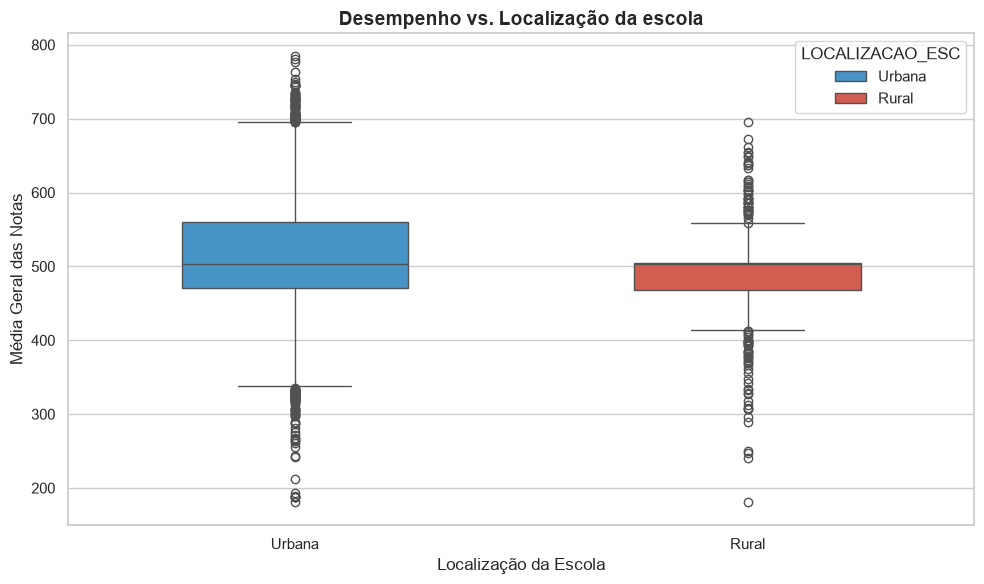

In [172]:
sns.boxplot(
    x='LOCALIZACAO_ESC', 
    y='MEDIA_GERAL', 
    data=df_escolas, 
    palette={'Urbana': '#3498db', 'Rural': '#e74c3c'}, # Cores contrastantes
    width=0.5,
    hue="LOCALIZACAO_ESC"
)

plt.title('Desempenho vs. Localização da escola', fontsize=14, fontweight='bold')
plt.xlabel('Localização da Escola')
plt.ylabel('Média Geral das Notas')
plt.tight_layout()
plt.show()


In [173]:
df_nulos_escola = df_escolas.isnull().sum().sort_values(ascending=False) # Contagem de nulos e ordenação decrescente
print(df_nulos_escola)

TP_SIT_FUNC_ESC           2770
SG_UF_ESC                 2770
CO_MUNICIPIO_ESC          2770
TP_DEPENDENCIA_ADM_ESC    2770
NO_MUNICIPIO_ESC          2770
CO_UF_ESC                 2770
TP_LOCALIZACAO_ESC        2770
LOCALIZACAO_ESC           2770
CO_PROVA_MT               1932
CO_PROVA_CN               1932
CO_PROVA_CH               1640
NU_NOTA_COMP3             1640
NU_NOTA_COMP5             1640
NU_NOTA_COMP2             1640
CO_PROVA_LC               1640
TP_STATUS_REDACAO         1640
NU_NOTA_COMP4             1640
NU_NOTA_COMP1             1640
TP_ENSINO                  439
TP_ESTADO_CIVIL              0
TP_SEXO                      0
TP_FAIXA_ETARIA              0
TP_COR_RACA                  0
CO_UF_PROVA                  0
CO_MUNICIPIO_PROVA           0
TP_PRESENCA_LC               0
SG_UF_PROVA                  0
TP_PRESENCA_MT               0
TP_PRESENCA_CN               0
TP_PRESENCA_CH               0
TP_NACIONALIDADE             0
TP_ANO_CONCLUIU              0
TP_ST_CO

Verificação dos outliers

Gráficos do dataframe de escolas


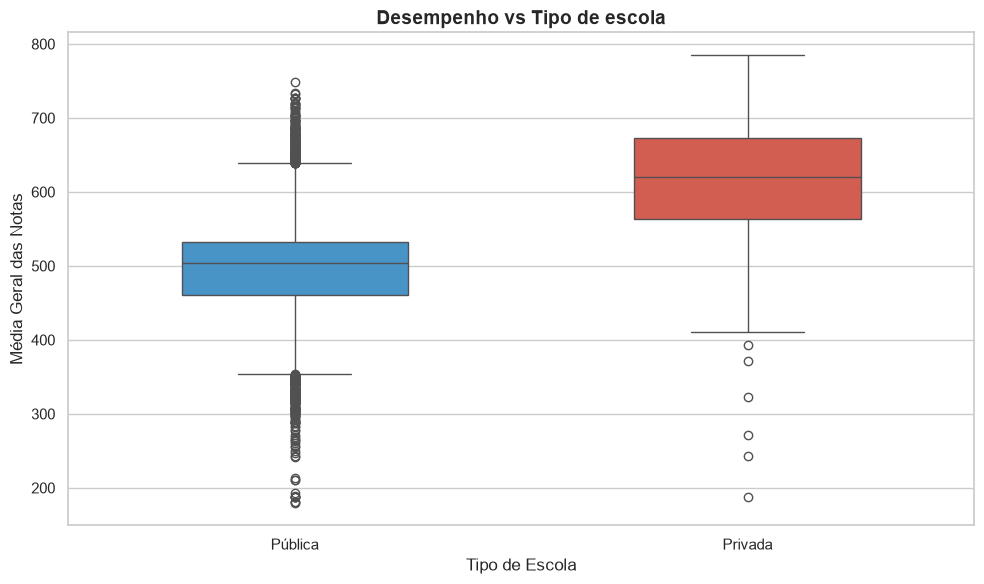

In [174]:
sns.boxplot(
    x='TP_ESCOLA', 
    y='MEDIA_GERAL', 
    data=df_escolas, 
    palette={'Pública': '#3498db', 'Privada': '#e74c3c'}, # Cores contrastantes
    hue='TP_ESCOLA',
    width=0.5
)

plt.title('Desempenho vs Tipo de escola', fontsize=14, fontweight='bold')
plt.xlabel('Tipo de Escola')
plt.ylabel('Média Geral das Notas')
plt.tight_layout()
plt.show()


# Mapeamento de colunas do questionário socioeconômico

In [175]:
# Colunas respectivamente: Escolaridade do pai, escolaridade da mãe, renda, celular, computador e internet.
# ["Q001", "Q002", "Q006","Q022","Q024","Q025"]

mapeamento_escolaridade = {
    'A': 1,
    'B': 2,
    'C': 2,
    'D': 3,
    'E' : 4,
    'F' : 5,
    'G' : 5,
}

# O que será mostrado no gráfico
labels_escolaridade = {
    1: 'Nunca estudou',
    2: 'Fundamental incompleto',
    3: 'Fundamental completo',
    4: 'Ensino médio completo',
    5: 'Superior completo',
}

# Guarda as escolaridades em ordem crescente
ordem_labels = [labels_escolaridade[i] for i in labels_escolaridade]

df_questionario = df_acre.copy()

Análise da correlação entre escolaridade do responsável e nota média do candidato

In [176]:
colunas_notas = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']
df_questionario['MEDIA_GERAL'] = df_questionario[colunas_notas].mean(axis=1)

# Mostra a média geral para cada resposta de Q002
analise_mae = df_questionario.groupby('Q002')['MEDIA_GERAL'].mean().reset_index()
display(analise_mae)

,Q002,MEDIA_GERAL
0,A,459.188216
1,B,474.732266
2,C,486.913008
3,D,492.810207
4,E,510.339688
5,F,542.508309
6,G,556.809427
7,H,480.724850


In [177]:
analise_pai = df_questionario.groupby('Q001')['MEDIA_GERAL'].mean().reset_index()
display(analise_pai)

,Q001,MEDIA_GERAL
0,A,468.566669
1,B,481.422680
2,C,495.692613
3,D,502.960069
4,E,519.489046
5,F,557.637237
6,G,563.564012
7,H,497.576880


Boxplots de Nota Média do Candidato vs. Escolaridade do responsável

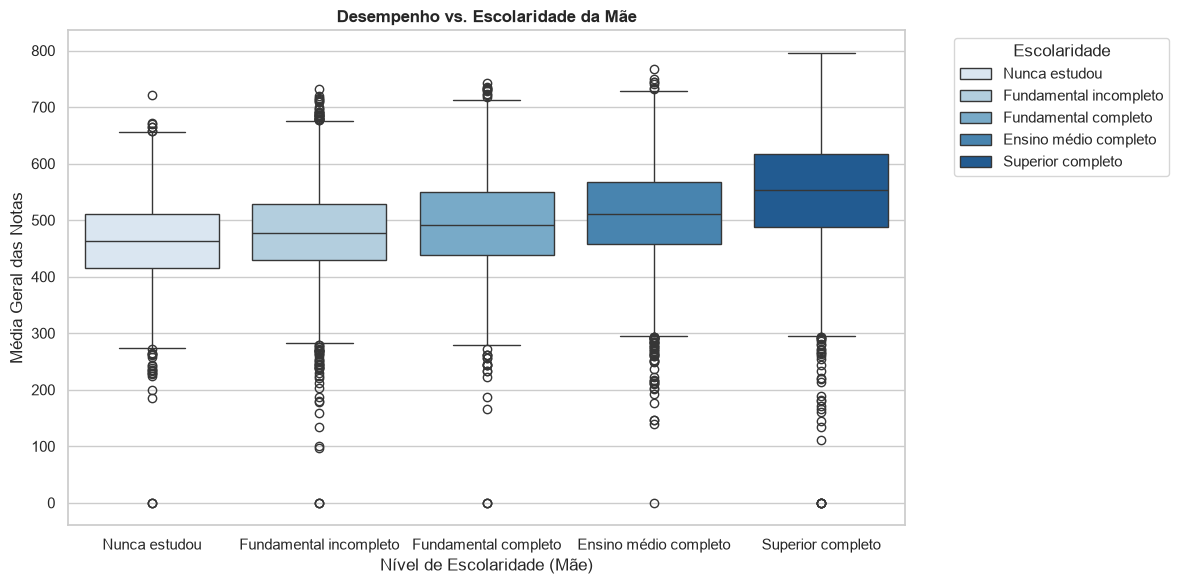

In [178]:
df_questionario['ROTULO_PAI'] = df_questionario['Q001'].map(mapeamento_escolaridade).map(labels_escolaridade)
df_questionario['ROTULO_MAE'] = df_questionario['Q002'].map(mapeamento_escolaridade).map(labels_escolaridade)

plt.figure(figsize=(12, 6)) 

sns.boxplot(
    x='ROTULO_MAE',
    y='MEDIA_GERAL',
    data=df_questionario,
    order=ordem_labels,
    palette='Blues',
    hue='ROTULO_MAE',
    hue_order=ordem_labels
)

plt.title('Desempenho vs. Escolaridade da Mãe', fontsize=12, fontweight='bold')
plt.xlabel('Nível de Escolaridade (Mãe)')
plt.ylabel('Média Geral das Notas')
plt.legend(title='Escolaridade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

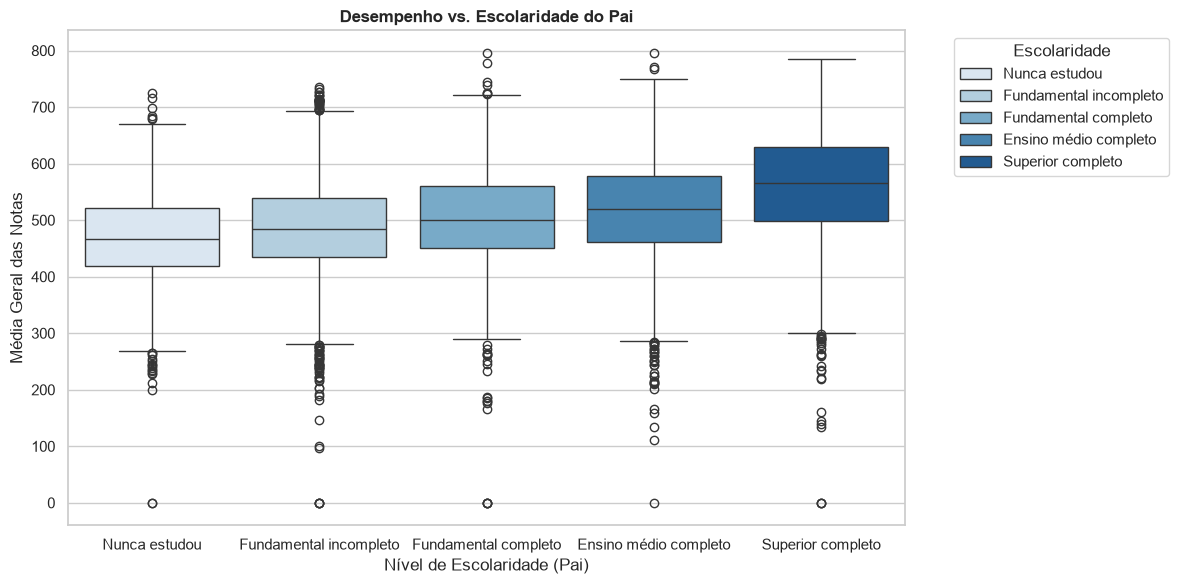

In [179]:
plt.figure(figsize=(12, 6)) 

# 2. Atualizando o eixo X para a coluna mapeada
sns.boxplot(
    x='ROTULO_PAI',       # Usando a coluna mapeada em vez de 'Q002'
    y='MEDIA_GERAL',
    data=df_questionario,
    order=ordem_labels,   # Agora o eixo X e a ordem possuem os mesmos textos
    palette='Blues',
    hue='ROTULO_PAI',
    hue_order=ordem_labels
)

plt.title('Desempenho vs. Escolaridade do Pai', fontsize=12, fontweight='bold')
plt.xlabel('Nível de Escolaridade (Pai)')
plt.ylabel('Média Geral das Notas')
plt.legend(title='Escolaridade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

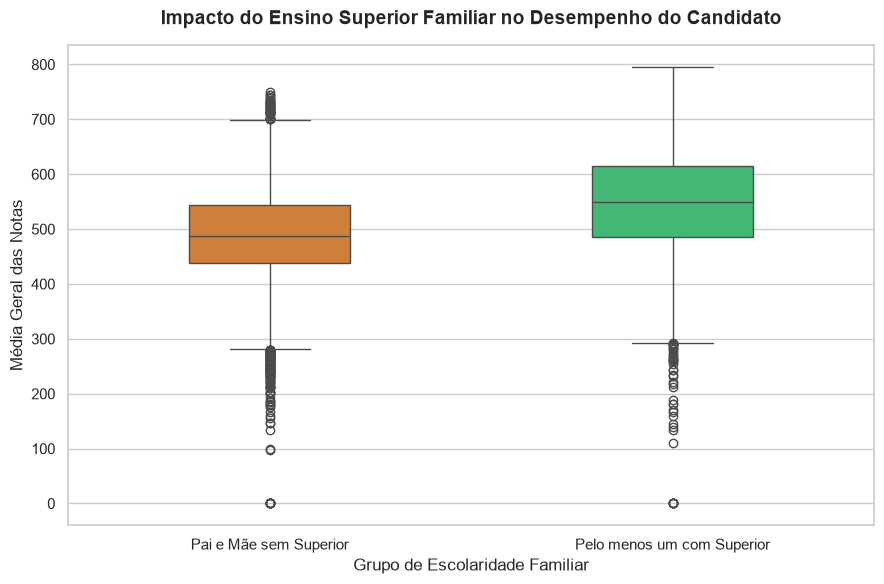

In [180]:
# Pega somente F e G que equivalem a graduação e pós graduação
pelo_menos_um_superior = df_questionario['Q001'].isin(['F', 'G']) | df_questionario['Q002'].isin(['F', 'G'])
ambos_sem_superior = ~pelo_menos_um_superior # Não tem pelo menos um com superior

df_grupos_escolaridade = df_questionario[pelo_menos_um_superior | ambos_sem_superior].copy() # COloca os dados em um novo df

# Cria uma coluna nova e onde a afirmação for verdadeira substitui pelo rotulo
df_grupos_escolaridade.loc[pelo_menos_um_superior, 'GRUPO_SUPERIOR'] = 'Pelo menos um com Superior' 
df_grupos_escolaridade.loc[ambos_sem_superior, 'GRUPO_SUPERIOR'] = 'Pai e Mãe sem Superior' 

plt.figure(figsize=(9, 6))
sns.boxplot(
    x='GRUPO_SUPERIOR',
    y='MEDIA_GERAL',
    data=df_grupos_escolaridade,
    # Agora a chave do dicionário bate exatamente com o DataFrame
    palette={'Pelo menos um com Superior': '#2ecc71', 'Pai e Mãe sem Superior': '#e67e22'},
    hue='GRUPO_SUPERIOR',
    legend=False,
    width=0.4
)

plt.title('Impacto do Ensino Superior Familiar no Desempenho do Candidato', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Grupo de Escolaridade Familiar', fontsize=12)
plt.ylabel('Média Geral das Notas', fontsize=12)
plt.tight_layout()
plt.show()

Mapeamento de renda familiar do candidato

Boxplot de Renda familiar x Desempenho

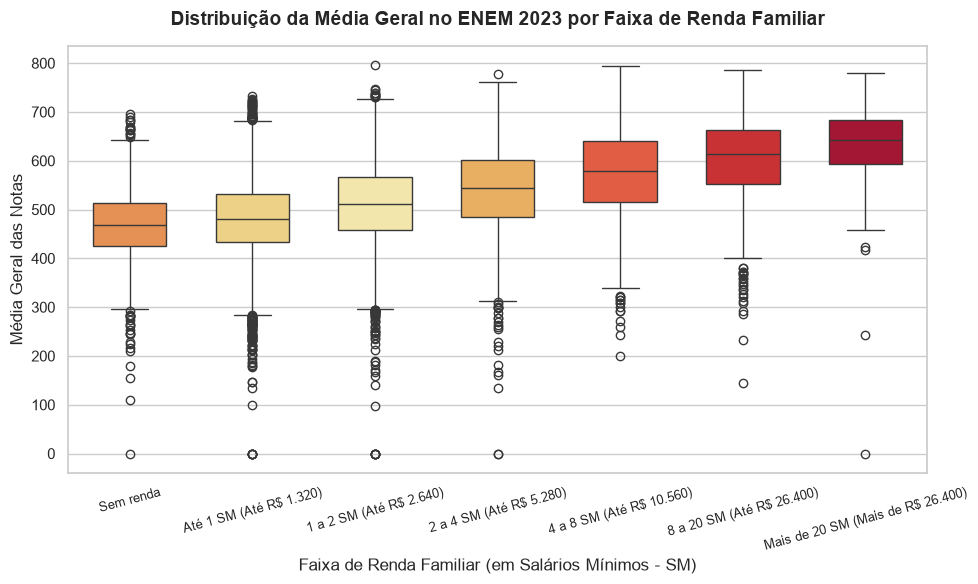

In [181]:
mapeamento_renda = {
    'A': 1,
    'B': 2,
    'C': 3, 'D': 3,
    'E': 4, 'F': 4, 'G': 4,
    'H': 5, 'I': 5, 'J': 5, 'K': 5,
    'L': 6, 'M': 6, 'N': 6, 'O': 6, 'P': 6,
    'Q': 7
}

df_renda = df_acre.copy()
df_renda['RENDA_FAMILIAR_NUM'] = df_renda['Q006'].map(mapeamento_renda)

df_renda['Q006'] = df_renda['Q006'].map(mapeamento_renda)
colunas_notas = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']
df_renda['MEDIA_GERAL'] = df_renda[colunas_notas].mean(axis=1)


labels_renda = {
    1: 'Sem renda',
    2: 'Até 1 SM (Até R$ 1.320)',
    3: '1 a 2 SM (Até R$ 2.640)',
    4: '2 a 4 SM (Até R$ 5.280)',
    5: '4 a 8 SM (Até R$ 10.560)',
    6: '8 a 20 SM (Até R$ 26.400)',
    7: 'Mais de 20 SM (Mais de R$ 26.400)'
}

ordem_renda = [labels_renda[i] for i in sorted(labels_renda.keys())]

df_renda['ROTULO_RENDA'] = df_renda['RENDA_FAMILIAR_NUM'].map(labels_renda)
ordem_renda = [labels_renda[i] for i in sorted(labels_renda.keys())]

sns.boxplot(
    x='ROTULO_RENDA',
    y='MEDIA_GERAL',
    data=df_renda,
    order=ordem_renda,
    palette='YlOrRd',
    hue='ROTULO_RENDA',
    legend=False,
    width=0.6
)

plt.title('Distribuição da Média Geral no ENEM 2023 por Faixa de Renda Familiar', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Faixa de Renda Familiar (em Salários Mínimos - SM)', fontsize=12)
plt.ylabel('Média Geral das Notas', fontsize=12)
plt.xticks(rotation=15, fontsize=9) # Rotacionando as faixas de texto para legibilidade

plt.tight_layout()
plt.show()

Análise de distribuição e Assimetria

In [182]:
skew_antes = df_acre[colunas_notas].skew()
df_acre = df_acre.loc[df_acre['NU_NOTA_REDACAO'] > 0]
skew_depois = df_acre[colunas_notas].skew()

print(skew_antes)


NU_NOTA_CN        -0.927896
NU_NOTA_CH        -0.760987
NU_NOTA_LC        -0.716834
NU_NOTA_MT         0.046204
NU_NOTA_REDACAO   -0.544573
dtype: float64


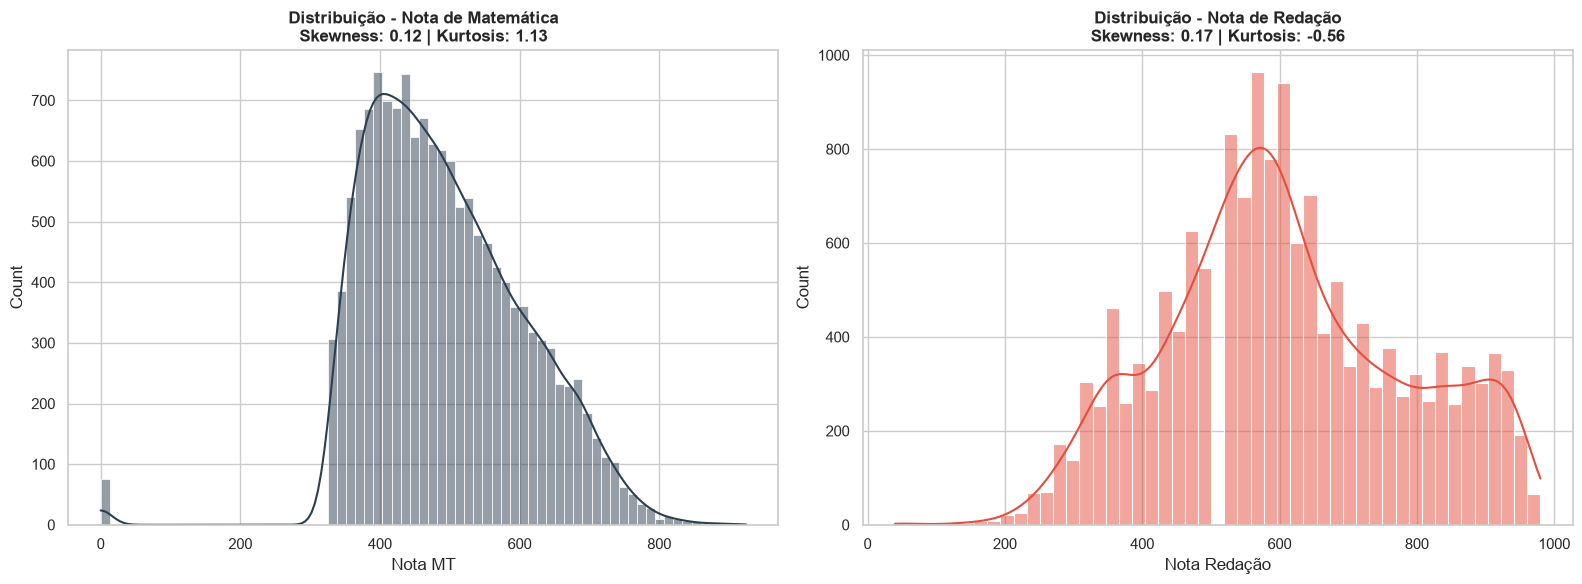

In [183]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6)) # Estrutura para dois gráficos em uma só figura

df_assimetria = df_acre.copy()

# Nota matemática
nota_mt = df_assimetria['NU_NOTA_MT'].dropna() # Removendo nulos para não quebrar o cálculo
skew_mt = nota_mt.skew() # Assimetria, verifica o quão "puxado" para os lados a curva está
kurt_mt = nota_mt.kurt() # Curtose, verifica o quão "pontudo" ou achatado o gráfico está

sns.histplot(ax=axes[0], x=nota_mt, kde=True, color='#2c3e50')
axes[0].set_title(f'Distribuição - Nota de Matemática\nSkewness: {skew_mt:.2f} | Kurtosis: {kurt_mt:.2f}', 
                  fontsize=12, 
                  fontweight='bold')
axes[0].set_xlabel('Nota MT')

# Nota redação

nota_red = df_assimetria.loc[df_assimetria['NU_NOTA_REDACAO'] > 0, 'NU_NOTA_REDACAO'] # Remove valores nulos e zeros
skew_red = nota_red.skew()
kurt_red = nota_red.kurt()

sns.histplot(ax=axes[1], x=nota_red, kde=True, color='#e74c3c')
axes[1].set_title(f'Distribuição - Nota de Redação\nSkewness: {skew_red:.2f} | Kurtosis: {kurt_red:.2f}', 
                  fontsize=12, 
                  fontweight='bold')
axes[1].set_xlabel('Nota Redação')

plt.tight_layout()
plt.show()

Matriz de correlação

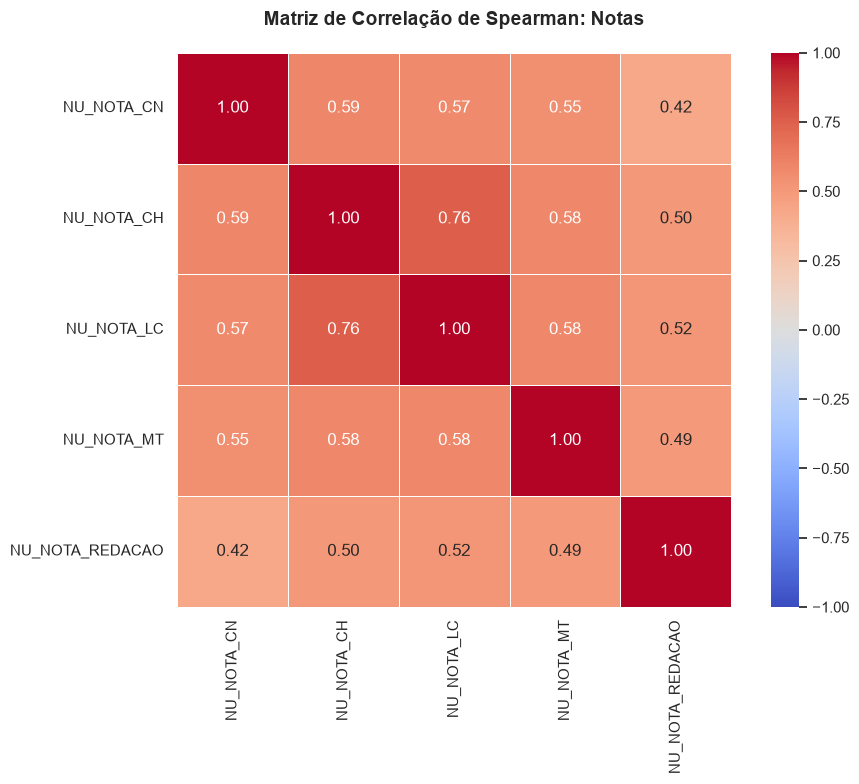

In [184]:
# Utilizando o método spearman para calcular a matriz
matriz_correlacao = df_questionario[colunas_notas].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.set_theme(style="white")

sns.heatmap(
    matriz_correlacao, 
    annot=True,     
    cmap='coolwarm',
    vmin=-1, vmax=1,
    fmt='.2f',      
    linewidths=0.5, 
    square=True     
)

plt.title('Matriz de Correlação de Spearman: Notas', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Como não houve nenhuma coluna com >= 0.8, não será necessária multicolineariedade

# Detecção de outliers

Criando df exclusivo para analisar candidatos que possuem a informação do tipo de escola

In [185]:
df_analise_escola = df_acre.copy()

# Apenas aquelees que possuem a informação do tipo de escola
df_analise_escola = df_analise_escola[df_analise_escola['TP_ESCOLA'].isin([2, 3])].copy()

df_analise_escola['ROTULO_ESCOLA'] = df_analise_escola['TP_ESCOLA'].map({2: 'Pública', 3: 'Privada'})

# Remove candidatos que faltaram ou foram eliminados 
colunas_notas = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']
df_analise_escola = df_analise_escola.dropna(subset=colunas_notas).copy()

# Cria coluna de media geral
df_analise_escola['MEDIA_GERAL'] = df_analise_escola[colunas_notas].mean(axis=1)

print(f"Linhas totais após filtros: {df_analise_escola.shape[0]}")
print(f"Colunas disponíveis para análise: {df_analise_escola.shape[1]}")


Linhas totais após filtros: 4840
Colunas disponíveis para análise: 67


Detecção de outliers utilizando IQR

In [186]:
Q1 = df_analise_escola['MEDIA_GERAL'].quantile(0.25)
Q3 = df_analise_escola['MEDIA_GERAL'].quantile(0.75)
IQR = Q3 - Q1

# Definir os limites
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtrar e separar os outliers da base limpa
outliers = df_analise_escola[
    (df_analise_escola['MEDIA_GERAL'] < limite_inferior) | 
    (df_analise_escola['MEDIA_GERAL'] > limite_superior)
]

df_escola_limpo = df_analise_escola[
    (df_analise_escola['MEDIA_GERAL'] >= limite_inferior) & 
    (df_analise_escola['MEDIA_GERAL'] <= limite_superior)
].copy()


Geração do gráfico antes vs. depois

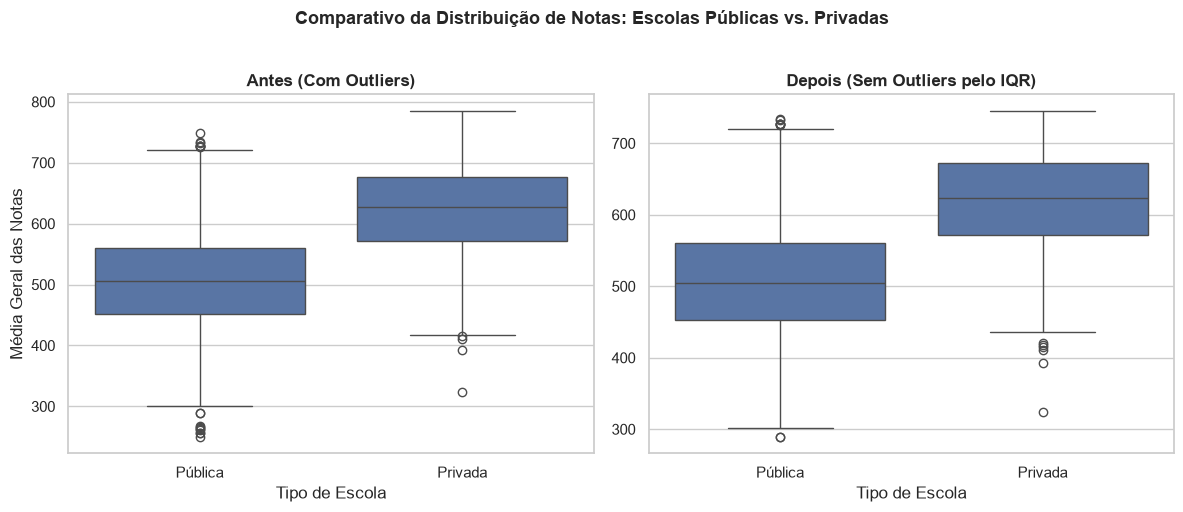

In [187]:
plt.figure(figsize=(12, 5))
sns.set_theme(style="whitegrid")

# Gráfico 1: Antes (Base com Outliers)
plt.subplot(1, 2, 1)
sns.boxplot(x='ROTULO_ESCOLA', y='MEDIA_GERAL', data=df_analise_escola)
plt.title('Antes (Com Outliers)', fontweight='bold')
plt.xlabel('Tipo de Escola')
plt.ylabel('Média Geral das Notas')

# Gráfico 2: Depois (Base Limpa pelo IQR)
plt.subplot(1, 2, 2)
sns.boxplot(x='ROTULO_ESCOLA', y='MEDIA_GERAL', data=df_escola_limpo)
plt.title('Depois (Sem Outliers pelo IQR)', fontweight='bold')
plt.xlabel('Tipo de Escola')
plt.ylabel('')

plt.suptitle('Comparativo da Distribuição de Notas: Escolas Públicas vs. Privadas', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Método Isolation Forest

Candidatos normais detectados: 4694
Outliers detectados: 146 (3.02%)


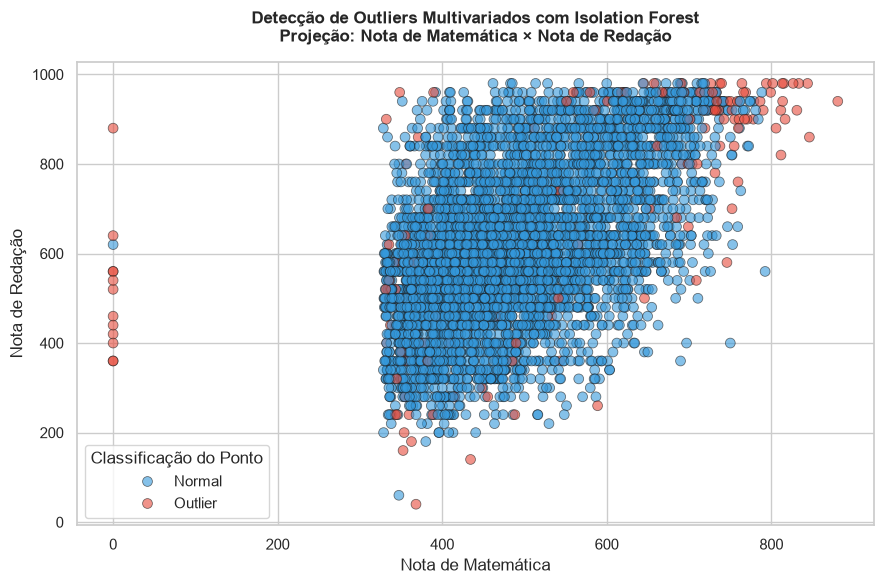

In [188]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

colunas_notas = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']

# Criar uma cópia de trabalho focada nas notas
df_multivariado = df_analise_escola.copy()

# Padronizar as notas (Média = 0, Desvio Padrão = 1_
scaler = StandardScaler()
notas_escaladas = scaler.fit_transform(df_multivariado[colunas_notas])

# Inicialização do algoritmo Isolation Forest
iso_forest = IsolationForest(contamination=0.03, random_state=42) # Contaminação de 3%
df_multivariado['outlier_iso'] = iso_forest.fit_predict(notas_escaladas)

# O Scikit-Learn mapeia: 1 para pontos normais (inliers) e -1 para anomalias (outliers)
df_multivariado['is_outlier_label'] = df_multivariado['outlier_iso'].map({1: 'Normal', -1: 'Outlier'})

# Exibe estatísticas
qtd_outliers = (df_multivariado['outlier_iso'] == -1).sum()
pct_outliers = (qtd_outliers / len(df_multivariado)) * 100

print(f"Candidatos normais detectados: {len(df_multivariado) - qtd_outliers}")
print(f"Outliers detectados: {qtd_outliers} ({pct_outliers:.2f}%)")

# Cruzamento da Nota de Matemática com a Nota de Redação
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_multivariado,
    x='NU_NOTA_MT',
    y='NU_NOTA_REDACAO',
    hue='is_outlier_label',
    palette={'Normal': '#3498db', 'Outlier': '#e74c3c'},
    alpha=0.6,
    edgecolor='k',
    s=50
)

plt.title('Detecção de Outliers Multivariados com Isolation Forest\nProjeção: Nota de Matemática × Nota de Redação', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Nota de Matemática')
plt.ylabel('Nota de Redação')
plt.legend(title='Classificação do Ponto')
plt.tight_layout()
plt.show()

Método LOF

Candidatos normais: 4694
Outliers: 146 (3.02%)


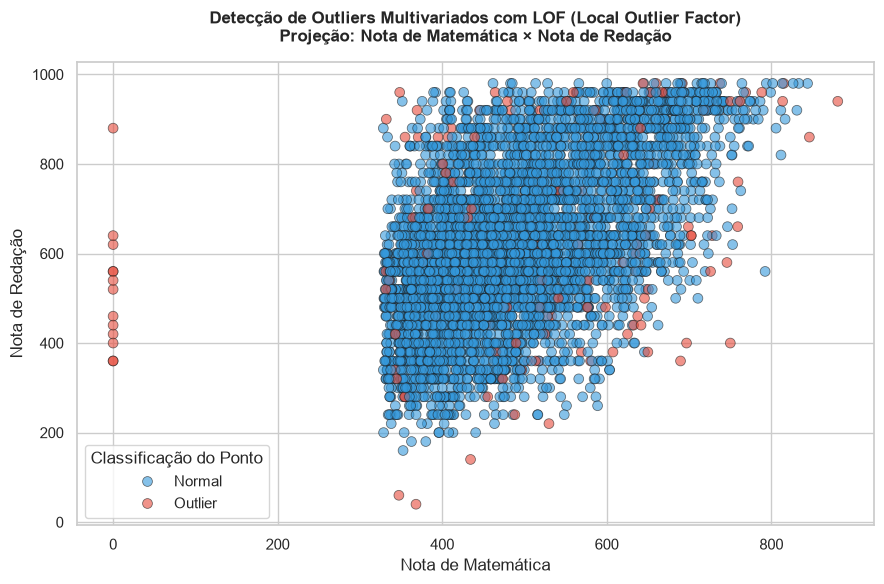

In [189]:
from sklearn.neighbors import LocalOutlierFactor

df_lof = df_analise_escola.copy()

scaler = StandardScaler()
notas_escaladas = scaler.fit_transform(df_lof[colunas_notas])

# Inicialização e treinamento do Local Outlier Factor (LOF)
# Usando 20 vizinhos (padrão recomendado no slide) e 3% de contaminação
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.03)
df_lof['outlier_lof'] = lof.fit_predict(notas_escaladas)

df_lof['is_outlier_label'] = df_lof['outlier_lof'].map({1: 'Normal', -1: 'Outlier'})

# Estatísticas
qtd_outliers = (df_lof['outlier_lof'] == -1).sum()
pct_outliers = (qtd_outliers / len(df_lof)) * 100

print(f"Candidatos normais: {len(df_lof) - qtd_outliers}")
print(f"Outliers: {qtd_outliers} ({pct_outliers:.2f}%)")

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_lof,
    x='NU_NOTA_MT',
    y='NU_NOTA_REDACAO',
    hue='is_outlier_label',
    palette={'Normal': '#3498db', 'Outlier': '#e74c3c'},
    alpha=0.6,
    edgecolor='k',
    s=50
)

plt.title('Detecção de Outliers Multivariados com LOF (Local Outlier Factor)\nProjeção: Nota de Matemática × Nota de Redação', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Nota de Matemática')
plt.ylabel('Nota de Redação')
plt.legend(title='Classificação do Ponto')
plt.tight_layout()
plt.show()

Método One-Class SVM

Candidatos normais: 4692
Outliers: 148 (3.06%)


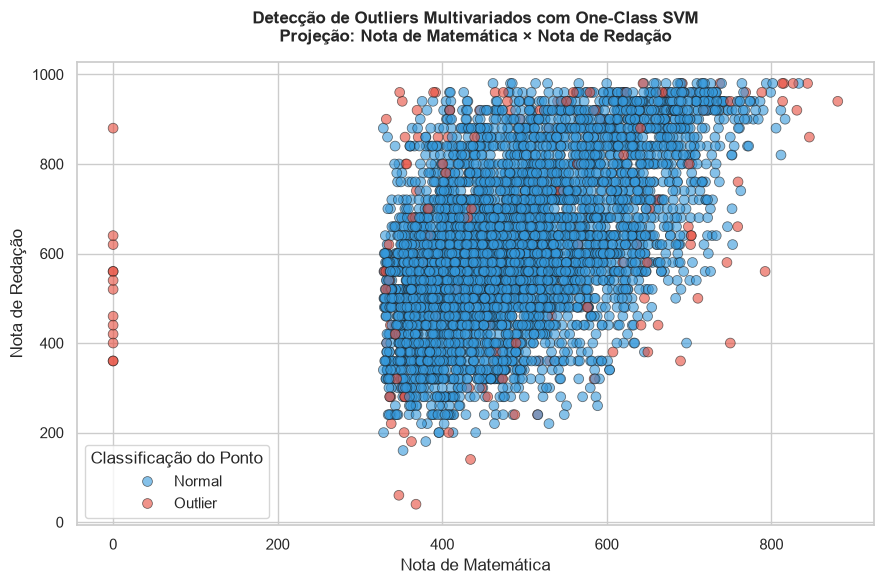

In [190]:
from sklearn.svm import OneClassSVM

df_svm = df_analise_escola.copy()

# Padroniza os dados (Média = 0, Desvio Padrão = 1) crítico para SVM
scaler = StandardScaler()
notas_escaladas = scaler.fit_transform(df_svm[colunas_notas])

# Inicializa e treina o One-Class SVM
# nu=0.03 representa o limite de 3% de anomalias esperadas
# Usando o kernel 'rbf' para permitir fronteiras curvas não lineares
oc_svm = OneClassSVM(nu=0.03, kernel='rbf', gamma='scale')
df_svm['outlier_svm'] = oc_svm.fit_predict(notas_escaladas)

df_svm['is_outlier_label'] = df_svm['outlier_svm'].map({1: 'Normal', -1: 'Outlier'})

# 5. Estatísticas
qtd_outliers = (df_svm['outlier_svm'] == -1).sum()
pct_outliers = (qtd_outliers / len(df_svm)) * 100

print(f"Candidatos normais: {len(df_svm) - qtd_outliers}")
print(f"Outliers: {qtd_outliers} ({pct_outliers:.2f}%)")

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_svm,
    x='NU_NOTA_MT',
    y='NU_NOTA_REDACAO',
    hue='is_outlier_label',
    palette={'Normal': '#3498db', 'Outlier': '#e74c3c'},
    alpha=0.6,
    edgecolor='k',
    s=50
)

plt.title('Detecção de Outliers Multivariados com One-Class SVM\nProjeção: Nota de Matemática × Nota de Redação', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Nota de Matemática')
plt.ylabel('Nota de Redação')
plt.legend(title='Classificação do Ponto')
plt.tight_layout()
plt.show()

Votação de outliers entre os métodos

Base Original : 4840 linhas
Base Limpa   : 4721 linhas
Candidatos Removidos     : 119


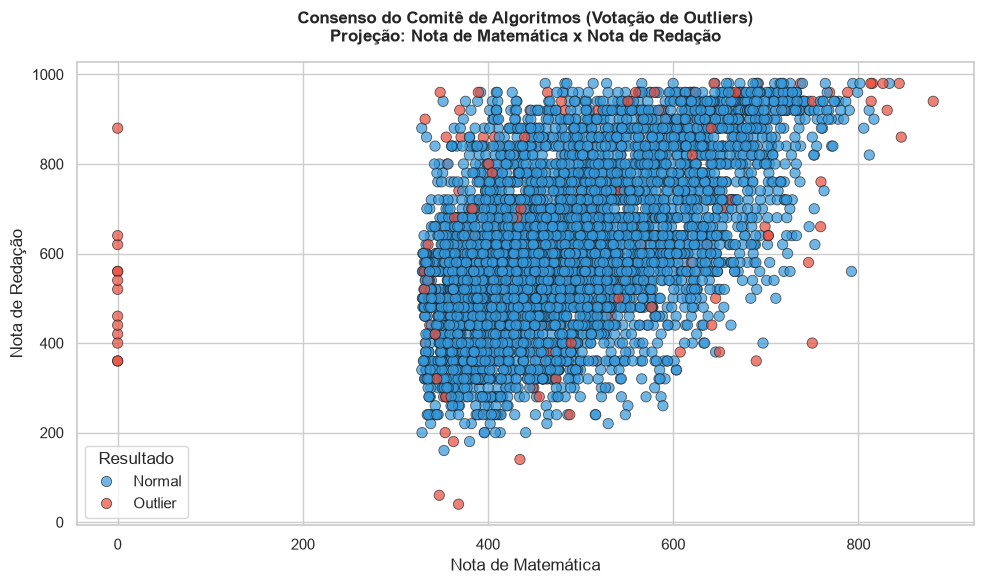

In [191]:
df_voto = df_analise_escola.copy()

scaler = StandardScaler()
notas_escaladas = scaler.fit_transform(df_voto[colunas_notas])

taxa_contaminacao = 0.03

# Isolation Forest
iso = IsolationForest(contamination=taxa_contaminacao, random_state=42)
df_voto['outlier_iso'] = iso.fit_predict(notas_escaladas)

# Local Outlier Factor
lof = LocalOutlierFactor(n_neighbors=20, contamination=taxa_contaminacao)
df_voto['outlier_lof'] = lof.fit_predict(notas_escaladas)

# One-Class SVM
svm = OneClassSVM(nu=taxa_contaminacao, kernel='rbf', gamma='scale')
df_voto['outlier_svm'] = svm.fit_predict(notas_escaladas)

# Calcula votação, soma tudo
df_voto['votos_outlier'] = (
    (df_voto['outlier_iso'] == -1).astype(int) +
    (df_voto['outlier_lof'] == -1).astype(int) +
    (df_voto['outlier_svm'] == -1).astype(int)
)

condicoes = [
    df_voto['votos_outlier'] == 0,
    df_voto['votos_outlier'] >= 2
]
escolhas = ['Normal', 'Outlier']
df_voto['STATUS_OUTLIER'] = np.select(condicoes, escolhas, default='Normal')

df_escola_limpo_multivariado = df_voto[df_voto['votos_outlier'] < 2].copy()

contagem_votos = df_voto['votos_outlier'].value_counts().sort_index()


print(f"Base Original : {len(df_voto)} linhas")
print(f"Base Limpa   : {len(df_escola_limpo_multivariado)} linhas")
print(f"Candidatos Removidos     : {len(df_voto) - len(df_escola_limpo_multivariado)}")

# 8. Gráfico do Consenso de Votos: Matemática × Redação
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    data=df_voto,
    x='NU_NOTA_MT',
    y='NU_NOTA_REDACAO',
    hue='STATUS_OUTLIER',
    palette={'Normal': '#3498db', 'Outlier': '#e74c3c'},
    alpha=0.7,
    edgecolor='k',
    s=55
)

plt.title('Consenso do Comitê de Algoritmos (Votação de Outliers)\nProjeção: Nota de Matemática x Nota de Redação', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Nota de Matemática')
plt.ylabel('Nota de Redação')
plt.legend(title='Resultado')
plt.tight_layout()
plt.show()

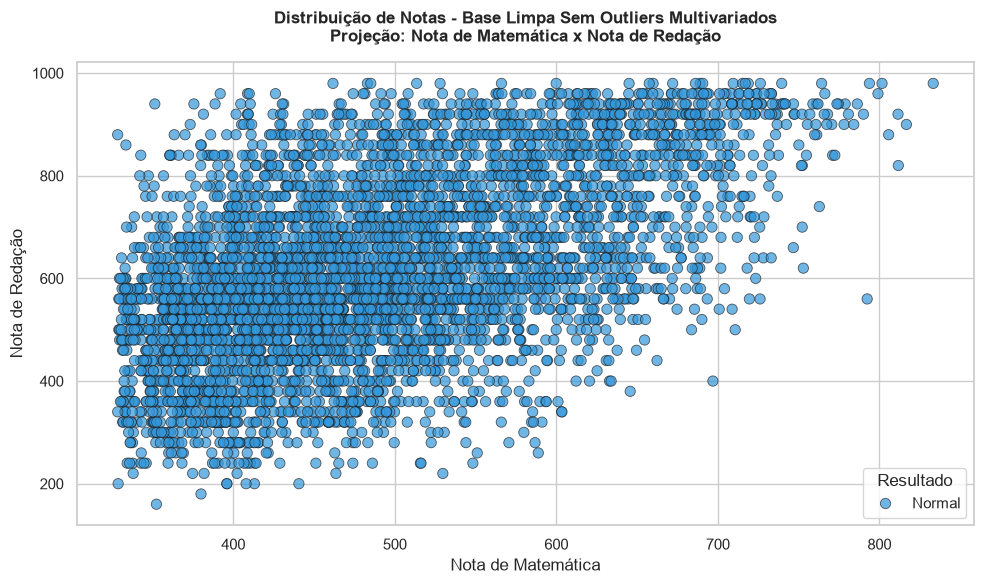

In [192]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    data=df_escola_limpo_multivariado, 
    x='NU_NOTA_MT',
    y='NU_NOTA_REDACAO',
    hue='STATUS_OUTLIER',
    palette={'Normal': '#3498db'}, 
    alpha=0.7,
    edgecolor='k',
    s=55
)

plt.title('Distribuição de Notas - Base Limpa Sem Outliers Multivariados\nProjeção: Nota de Matemática x Nota de Redação', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Nota de Matemática')
plt.ylabel('Nota de Redação')
plt.legend(title='Resultado')
plt.tight_layout()
plt.show()

Criando dataframe para análise geral

In [193]:
df_analise_geral = df_acre.copy()

# Remove quem faltou ou foi eliminado
colunas_notas = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']
df_analise_geral = df_analise_geral.dropna(subset=colunas_notas).copy()

# Cria coluna de média geral
df_analise_geral['MEDIA_GERAL'] = df_analise_geral[colunas_notas].mean(axis=1)

# Mapeamento da renda para numérico
mapeamento_renda = {
    'A': 1, 
    'B': 2, 
    'C': 3, 'D': 3, 
    'E': 4, 'F': 4, 'G': 4,
    'H': 5, 'I': 5, 'J': 5, 'K': 5, 
    'L': 6, 'M': 6, 'N': 6, 'O': 6, 'P': 6, 
    'Q': 7
}
df_analise_geral['RENDA_FAMILIAR_NUM'] = df_analise_geral['Q006'].map(mapeamento_renda)

mapeamento_escolaridade = {
    'A': 1,          # Nunca estudou
    'B': 2, 'C': 2,  # Não completou fundamental
    'D': 3,          # Fundamental completo
    'E': 4,          # Ensino médio completo
    'F': 5, 'G': 5,  # Ensino superior completo (Faculdade / Pós)
    'H': 6           # Não sei
}
df_analise_geral['ESCOLARIDADE_PAI_NUM'] = df_analise_geral['Q001'].map(mapeamento_escolaridade)
df_analise_geral['ESCOLARIDADE_MAE_NUM'] = df_analise_geral['Q002'].map(mapeamento_escolaridade)

# Separação entre pelo menos um responsável com superior e nenhum responsável com superior
pelo_menos_um_superior = (df_analise_geral['ESCOLARIDADE_PAI_NUM'] == 5) | (df_analise_geral['ESCOLARIDADE_MAE_NUM'] == 5)
ambos_sem_superior = (df_analise_geral['ESCOLARIDADE_PAI_NUM'] != 5) & (df_analise_geral['ESCOLARIDADE_MAE_NUM'] != 5)

condicoes = [pelo_menos_um_superior, ambos_sem_superior]
escolhas = ['Pelo menos um com Superior', 'Pai E Mãe sem Superior']
df_analise_geral['GRUPO_SUPERIOR'] = np.select(condicoes, escolhas, default=None)

print(f"Linhas disponíveis para análise: {df_analise_geral.shape[0]}")
print(f"Colunas disponíveis: {df_analise_geral.shape[1]}")

Linhas disponíveis para análise: 14617
Colunas disponíveis: 70
